# 3. 데이터베이스 (Database) & 스토리지


In [1]:
!pip install pandas numpy ipython matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. RDBMS vs NoSQL (확장성 비교 시각화)

데이터가 쌓일 때 인프라를 어떻게 늘릴 것인가에 대한 문제(Scalability)입니다.

* **RDBMS (정형 데이터)**:
결제 내역처럼 형태가 명확한 데이터입니다. 데이터 볼륨이 커질 때 RDBMS는 기존 서버의 CPU나 메모리 스펙을 높이는 **Scale-up** 방식을 주로 사용합니다. 아래 그래프의 빨간 선을 보시면, 트래픽이 증가할수록 고사양 장비가 필요해져 비용이 기하급수적으로 폭증함을 알 수 있습니다.

* **NoSQL (비정형 로그 데이터)**:
접속 로그나 센서 데이터처럼 형태가 불규칙한 데이터입니다. NoSQL은 데이터가 늘어날 때 저렴한 서버 대수를 옆으로 늘리는 **Scale-out** 방식에 최적화되어 있습니다. 아래 그래프의 파란 선처럼 데이터 볼륨이 증가해도 인프라 확장이 선형적이고 안정적으로 유지됩니다.

=== [데이터 구조의 차이] ===


,id,name
0,1,Alice



[NoSQL] JSON 구조: [
  {
    "user": "Alice",
    "action": "click"
  }
]


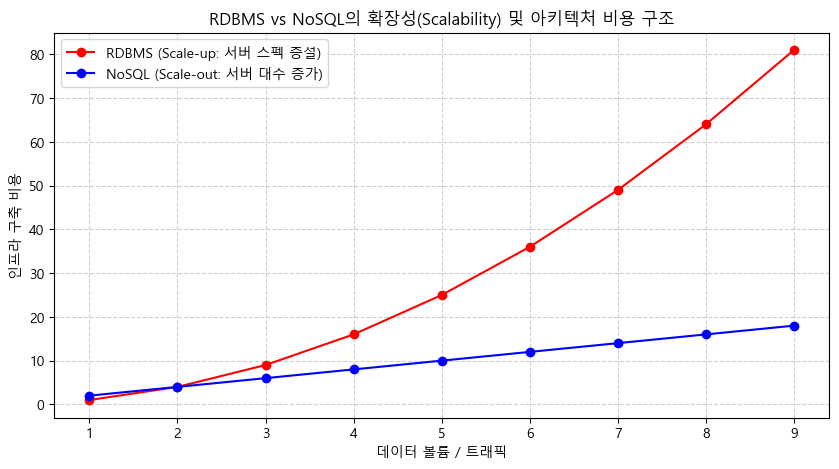

In [2]:
import sqlite3
import pandas as pd
import json
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. RDBMS / NoSQL 간단 출력 예시
print("=== [데이터 구조의 차이] ===")
conn = sqlite3.connect(':memory:')
conn.execute('''CREATE TABLE users (id INTEGER, name TEXT)''')
conn.execute("INSERT INTO users VALUES (1, 'Alice')")
display(pd.read_sql_query("SELECT * FROM users", conn))
print("\n[NoSQL] JSON 구조:", json.dumps([{"user": "Alice", "action": "click"}], indent=2))

# [시각화] RDBMS Scale-up vs NoSQL Scale-out 비용 구조 비교
data_volume = np.arange(1, 10)
rdbms_cost = data_volume ** 2 # Scale-up (기하급수적 비용)
nosql_cost = data_volume * 2  # Scale-out (선형적 비용)

plt.figure(figsize=(10, 5))
plt.plot(data_volume, rdbms_cost, 'r-o', label='RDBMS (Scale-up: 서버 스펙 증설)')
plt.plot(data_volume, nosql_cost, 'b-o', label='NoSQL (Scale-out: 서버 대수 증가)')
plt.title('RDBMS vs NoSQL의 확장성(Scalability) 및 아키텍처 비용 구조')
plt.xlabel('데이터 볼륨 / 트래픽')
plt.ylabel('인프라 구축 비용')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. 데이터 웨어하우스(DW) & 데이터 레이크 (BI 시각화)

수집된 데이터들을 머신러닝 학습이나 분석에 쓰기 위해 통합하는 과정입니다.

* **데이터 레이크 (Data Lake)**: 모든 원시 로그 파일(텍스트, 이미지 등)을 스키마 없이 일단 다 모아두는 저장소입니다.
* **데이터 웨어하우스 (Data Warehouse)**: 데이터 레이크의 원시 데이터들을 정제(ETL)하여 다차원으로 집계한 구조화된 저장소입니다. 

아래 코드는 데이터 레이크에 흩어져 있던 단순한 접속 기록들이, 데이터 웨어하우스를 거쳐 어떻게 **'유저별 구매 행동(Buy Count)'** 이라는 의미 있는 지표로 정제되는지 보여줍니다. 이렇게 구조화된 데이터는 시각화(BI) 대시보드로 바로 연결되어 강력한 인사이트를 제공합니다.

=== [DW 집계 완료 테이블] ===


,user_id,buy_count
0,1,3
1,2,1


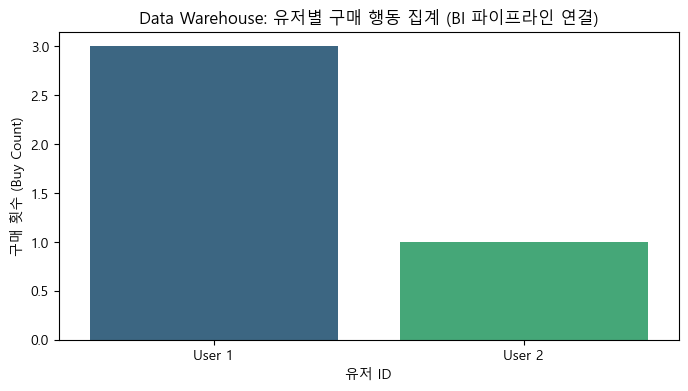

In [3]:
import seaborn as sns

# DW 집계 가상 데이터 시뮬레이션
dw_data = pd.DataFrame({
    'user_id': [1, 2, 1, 1, 2, 3],
    'action': ['buy', 'view', 'buy', 'buy', 'buy', 'view']
})
summary_table = dw_data[dw_data['action'] == 'buy'].groupby('user_id').size().reset_index(name='buy_count')

print("=== [DW 집계 완료 테이블] ===")
display(summary_table)

# [시각화] DW 집계 데이터 기반 BI 시각화
plt.figure(figsize=(8, 4))
sns.barplot(data=summary_table, x='user_id', y='buy_count', palette='viridis')
plt.title('Data Warehouse: 유저별 구매 행동 집계 (BI 파이프라인 연결)')
plt.xlabel('유저 ID')
plt.ylabel('구매 횟수 (Buy Count)')
plt.xticks(ticks=range(len(summary_table['user_id'])), labels=[f'User {u}' for u in summary_table['user_id']])
plt.show()

## 3. 벡터 데이터베이스 (Vector DB) (3D 벡터 공간 시각화)

최근 대형 언어 모델(LLM)과 검색 증강 생성(RAG)의 핵심 인프라입니다. 기존 DB처럼 텍스트 단어를 똑같이 매칭하는 것이 아니라, AI가 문서를 수치화한 **'임베딩 벡터(Embedding Vector)'**를 저장합니다.

아래 3D 그래프를 확인해 보세요.
* 파란색 화살표는 'MLOps 문서', 초록색 화살표는 'K8s 문서'를 3차원 벡터로 나타낸 것입니다.
* 빨간색 화살표는 사용자의 '질의(Query)'입니다.

벡터 DB는 이 3차원(실제로는 수천 차원) 공간에서 질의 화살표와 기존 문서 화살표들 사이의 **각도(코사인 유사도)**를 계산합니다. 아래 출력 결과를 보시면, 글자가 완벽히 똑같지 않아도 질의(빨간선)와 가장 방향이 겹치는 문서1(파란선)을 즉시 찾아냄을 직관적으로 확인할 수 있습니다.

문서 1('MLOps')과의 유사도: 0.9899
문서 2('K8s')과의 유사도: 0.3147



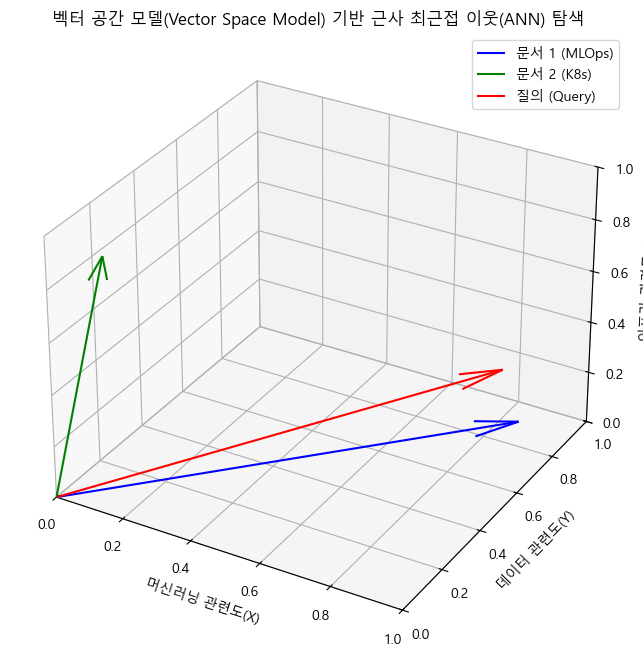

In [4]:
import numpy as np

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# 임베딩 벡터 공간 시뮬레이션: [머신러닝 관련성, 데이터 관련성, 인프라 관련성]
doc1_vector = np.array([0.9, 0.8, 0.1])  # 'MLOps 데이터 파이프라인'
doc2_vector = np.array([0.1, 0.1, 0.9])  # '쿠버네티스 서버 구축'
query_vector = np.array([0.8, 0.9, 0.2]) # 질의: "ML 데이터 저장소"

print(f"문서 1('MLOps')과의 유사도: {cosine_similarity(query_vector, doc1_vector):.4f}")
print(f"문서 2('K8s')과의 유사도: {cosine_similarity(query_vector, doc2_vector):.4f}\n")

# [시각화] 임베딩 벡터 3D 공간 플로팅
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

origin = [0, 0, 0]
ax.quiver(*origin, *doc1_vector, color='blue', arrow_length_ratio=0.1, label="문서 1 (MLOps)")
ax.quiver(*origin, *doc2_vector, color='green', arrow_length_ratio=0.1, label="문서 2 (K8s)")
ax.quiver(*origin, *query_vector, color='red', arrow_length_ratio=0.1, label="질의 (Query)")

ax.set_xlim([0, 1.0]); ax.set_ylim([0, 1.0]); ax.set_zlim([0, 1.0])
ax.set_xlabel('머신러닝 관련도(X)')
ax.set_ylabel('데이터 관련도(Y)')
ax.set_zlabel('인프라 관련도(Z)')
ax.set_title('벡터 공간 모델(Vector Space Model) 기반 근사 최근접 이웃(ANN) 탐색')
plt.legend()
plt.show()

## 4. 객체 스토리지 (Object Storage) (버저닝 및 롤백 추적)

머신러닝 파이프라인의 최종 산출물인 무거운 모델 가중치(Weight) 파일 등을 보관하는 버킷(Bucket) 형태의 저장소입니다.

MLOps에서 객체 스토리지가 중요한 가장 큰 이유는 **데이터 불변성(Immutability)과 버저닝(Versioning)** 입니다.
아래 이중 Y축 그래프를 확인해 보세요.
* 파란 막대는 모델 가중치 파일의 크기, 빨간 선은 모델의 성능(Accuracy)입니다.
* v1.2 버전이 배포되었을 때 성능이 급감하는 치명적인 모델 드리프트(Drift) 현상이 발생했습니다.

객체 스토리지는 기존 버전(v1.1)의 파일을 지우거나 덮어쓰지 않고 타임스탬프와 함께 완벽히 보존합니다. 덕분에 엔지니어는 시스템이 망가졌을 때 즉각적으로 안전했던 과거 버전(v1.1)으로 롤백하여 서비스를 정상화할 수 있습니다.

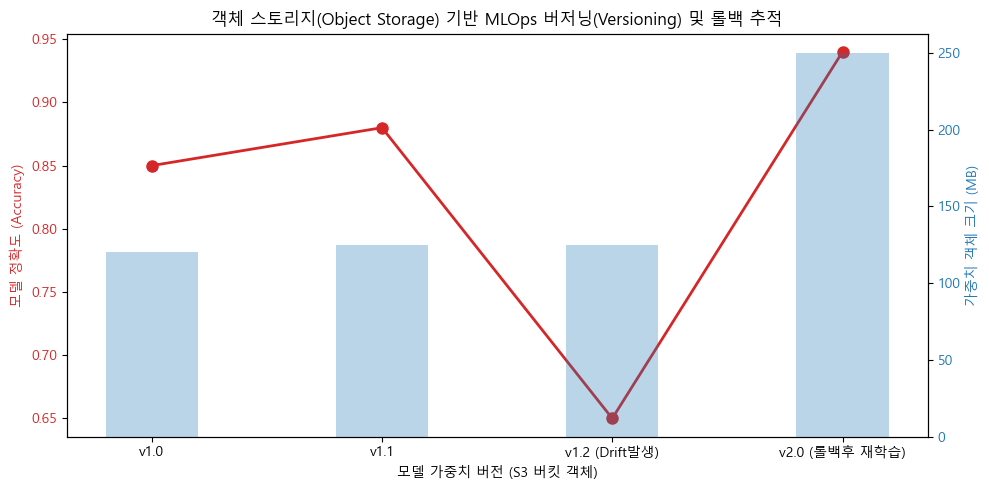

In [5]:
import matplotlib.pyplot as plt

# [시각화] 객체 스토리지 버저닝 추적 대시보드
versions = ['v1.0', 'v1.1', 'v1.2 (Drift발생)', 'v2.0 (롤백후 재학습)']
accuracy = [0.85, 0.88, 0.65, 0.94]  # 모델 정확도 추이
file_size_mb = [120, 125, 125, 250]  # 가중치 파일 크기 (MB)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('모델 가중치 버전 (S3 버킷 객체)')
ax1.set_ylabel('모델 정확도 (Accuracy)', color=color)
ax1.plot(versions, accuracy, marker='o', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('가중치 객체 크기 (MB)', color=color)  
ax2.bar(versions, file_size_mb, alpha=0.3, color=color, width=0.4)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('객체 스토리지(Object Storage) 기반 MLOps 버저닝(Versioning) 및 롤백 추적')
fig.tight_layout()
plt.show()